# Prepareation

In [1]:
import requests
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

API_KEY = 'jnl-JWIkbXDZ5fARfOHsjr6VNXIhE7cWVmGShW70sIN8KDiUOMZfrlQ8wOnsq_D8ofubFtBrOVWd02babZgmMNEd12pRmdLovzrML9YgjbTCVKPNuLGK9V2eHUYVZ3Yx'
HEADERS = {'Authorization':f'Bearer {API_KEY}'}

# Data From Related Coffee Stores

In [2]:
# Yelp API endpoint
url = "https://api.yelp.com/v3/businesses/search"

## Blue Bottle Coffee on Manhattan

In [3]:
# Parameters for the API request
params = {
    'term':'Blue Bottle Coffee',
    'location': 'New York City',
    'categories': 'Coffee',
    'limit': 50
}

In [4]:
# Make the request to the Yelp API
response = requests.get(url, headers=HEADERS, params=params)

# Parse the response JSON
data = response.json()

# Check if 'businesses' key exists in the response
if 'businesses' in data:
    businesses = data['businesses']

    # Extract business information from JSON
    store_list = []
    for business in businesses:
        store_info = {
            "Name": business.get("name"),
            "Address": ", ".join(business["location"]["display_address"]),
            "Latitude": business["coordinates"]["latitude"],
            "Longitude": business["coordinates"]["longitude"],
            "Zip Code": business["location"].get("zip_code", "N/A"),
            "Rating": business.get("rating"),
            "Review Count": business.get("review_count"),
            "Price": business.get("price", "N/A"),  
        }
        store_list.append(store_info)

    # Create a DataFrame from the extracted data
    df = pd.DataFrame(store_list)

df.head()

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price
0,Blue Bottle Coffee,"22 Broad St, New York, NY 10005",40.706510,-74.01123,10005,4.3,22,N/A
1,Blue Bottle Coffee,"396 Broadway, New York, NY 10013",40.718480,-74.00248,10013,4.1,37,$$
2,Blue Bottle Coffee - New York,"150 Greenwich St, New York, NY 10007",40.710715,-74.01233,10007,4.2,175,$$
3,Blue Bottle Coffee - Dean St,"85 Dean St, Brooklyn, NY 11201",40.687360,-73.98977,11201,4.3,152,$$
4,Blue Bottle Coffee,"408 Greenwich St, New York, NY 10013",40.721594,-74.01001,10013,3.4,8,N/A


In [5]:
df.dtypes

Name             object
Address          object
Latitude        float64
Longitude       float64
Zip Code         object
Rating          float64
Review Count      int64
Price            object
dtype: object

In [6]:
# filter out the rows where the store name is not "Blue Bottle Coffee" and ZIP codes are outside Manhattan's range (10001–10282)
df['Zip Code'] = df['Zip Code'].astype(int)
df_blue = df[
    (df['Name'].str.contains("Blue Bottle Coffee")) & 
    (df['Zip Code'].between(10001, 10282)) 
]
df_blue

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price
0,Blue Bottle Coffee,"22 Broad St, New York, NY 10005",40.706510,-74.011230,10005,4.3,22,N/A
1,Blue Bottle Coffee,"396 Broadway, New York, NY 10013",40.718480,-74.002480,10013,4.1,37,$$
2,Blue Bottle Coffee - New York,"150 Greenwich St, New York, NY 10007",40.710715,-74.012330,10007,4.2,175,$$
4,Blue Bottle Coffee,"408 Greenwich St, New York, NY 10013",40.721594,-74.010010,10013,3.4,8,N/A
6,Blue Bottle Coffee,"101 University Pl, New York, NY 10003",40.734030,-73.992520,10003,4.1,62,$
8,Blue Bottle Coffee,"1227 Broadway, New York, NY 10001",40.746621,-73.988791,10001,3.9,11,N/A
9,Blue Bottle Coffee,"1 Pennsylvania Plaza, Ste 135, New York, NY 10119",40.751186,-73.992120,10119,3.3,8,N/A
10,Blue Bottle Coffee,"441 8th Ave, Ste 68, New York, NY 10001",40.751537,-73.995835,10001,3.7,20,N/A
11,Blue Bottle Coffee - Grand Central Place,"60 E 42nd St, Ste 140, New York, NY 10165",40.752060,-73.978856,10165,3.8,54,$$
12,Blue Bottle Coffee - Hudson Yards,"20 Hudson Yards, Ste 228, New York, NY 10001",40.753119,-74.001823,10001,3.5,97,$$


In [7]:
df_blue.to_csv("blue_bottle_coffee_manhattan.csv", index=False)
print("CSV file saved successfully.")

CSV file saved successfully.


## Joe Coffee Company on Manhattan

In [8]:
params_2 = {
    'term':'Joe Coffee Company',
    'location': 'New York City',
    'categories': 'Coffee',
    'limit':50
}

In [40]:
# Make the request to the Yelp API
response_2 = requests.get(url, headers=HEADERS, params=params_2)

# Parse the response JSON
data_2 = response_2.json()

# Check if 'businesses' key exists in the response
if 'businesses' in data_2:
    businesses = data_2['businesses']

    # Extract business information from JSON
    store_list_2 = []
    for business in businesses:
        store_info_2 = {
            "Name": business.get("name"),
            "Address": ", ".join(business["location"]["display_address"]),
            "Latitude": business["coordinates"]["latitude"],
            "Longitude": business["coordinates"]["longitude"],
            "Zip Code": business["location"].get("zip_code", "N/A"),
            "Rating": business.get("rating"),
            "Review Count": business.get("review_count"),
            "Price": business.get("price", "N/A")
        }
        store_list_2.append(store_info_2)

    # Create a DataFrame from the extracted data
    df_2 = pd.DataFrame(store_list_2)

df_2

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price
0,Joe Coffee Company,"102 Hicks St, Brooklyn, NY 11201",40.698673,-73.994358,11201,3.8,78,$$
1,Joe Coffee Company,"141 Waverly Pl, New York, NY 10014",40.733297,-74.000566,10014,4.1,380,$
2,Joe Coffee Company,"9 E 13th St, New York, NY 10003",40.735171,-73.993262,10003,3.9,359,$$
3,Joe Coffee Company,"185 Greenwich St, LL3110, New York, NY 10007",40.712628,-74.012820,10007,4.0,29,$$
4,Joe Coffee Company,"7 South St Slip, New York, NY 10004",40.701345,-74.011612,10004,3.4,18,N/A
5,Joe Coffee Company,"29 Union Sq W, New York, NY 10003",40.736512,-73.991070,10003,4.1,15,N/A
6,Joe Coffee Company,"514 Columbus Ave, New York, NY 10024",40.785768,-73.972978,10024,4.0,396,$
7,Joe Coffee Company,"405 W 23rd St, New York, NY 10011",40.746902,-74.001670,10011,3.8,177,$$
8,Joe Coffee Company,"187 Columbus Ave, New York, NY 10023",40.775080,-73.980367,10023,4.0,143,$
9,Joe Coffee Company,"4037 23rd St, City, NY 11101",40.753312,-73.940044,11101,4.1,30,N/A


In [10]:
df_2.dtypes

Name             object
Address          object
Latitude        float64
Longitude       float64
Zip Code         object
Rating          float64
Review Count      int64
Price            object
dtype: object

In [11]:
# filter out the rows where the store name is not "Blue Bottle Coffee" and ZIP codes are outside Manhattan's range (10001–10282)
df_2['Zip Code'] = df['Zip Code'].astype(int)
df_joe = df_2[
    (df_2['Name']=='Joe Coffee Company')&
    (df_2['Address'].str.contains("New York, NY")) & 
    (df_2['Zip Code'].between(10001, 10282)) 
]
df_joe

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price
1,Joe Coffee Company,"141 Waverly Pl, New York, NY 10014",40.733297,-74.000566,10013,4.1,380,$
2,Joe Coffee Company,"9 E 13th St, New York, NY 10003",40.735171,-73.993262,10007,3.9,359,$$
4,Joe Coffee Company,"7 South St Slip, New York, NY 10004",40.701345,-74.011612,10013,3.4,18,N/A
6,Joe Coffee Company,"514 Columbus Ave, New York, NY 10024",40.785768,-73.972978,10003,4.0,396,$
8,Joe Coffee Company,"187 Columbus Ave, New York, NY 10023",40.775080,-73.980367,10001,4.0,143,$
10,Joe Coffee Company,"1045 Lexington Ave, New York, NY 10021",40.772044,-73.960805,10001,4.1,261,$
11,Joe Coffee Company,"550 W 120th St, New York, NY 10027",40.810050,-73.962020,10165,3.8,216,$$
12,Joe Coffee Company,"55 W 40th St, Ste 9, Bryant Park, New York, NY...",40.753458,-73.984319,10001,3.3,26,$$
13,Joe Coffee Company,"105 E 42nd St Grand Central Dining Concourse, ...",40.752731,-73.977233,10018,4.1,9,N/A
24,Joe Coffee Company,"305 Dodge Hall, 305 Dodge Hall, Upper Campus L...",40.810686,-73.961453,10019,5.0,6,N/A


In [12]:
import re

# Define a function to extract ZIP code from the address using regex
def extract_zip(address):
    match = re.search(r'\b\d{5}\b', address)
    if match:
        return match.group(0)  
    else:
        return None  

# Apply the function to the Address column and update the Zip Code column
df_joe['Zip Code'] = df_joe['Address'].apply(extract_zip)
df_joe

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price
1,Joe Coffee Company,"141 Waverly Pl, New York, NY 10014",40.733297,-74.000566,10014,4.1,380,$
2,Joe Coffee Company,"9 E 13th St, New York, NY 10003",40.735171,-73.993262,10003,3.9,359,$$
4,Joe Coffee Company,"7 South St Slip, New York, NY 10004",40.701345,-74.011612,10004,3.4,18,N/A
6,Joe Coffee Company,"514 Columbus Ave, New York, NY 10024",40.785768,-73.972978,10024,4.0,396,$
8,Joe Coffee Company,"187 Columbus Ave, New York, NY 10023",40.775080,-73.980367,10023,4.0,143,$
10,Joe Coffee Company,"1045 Lexington Ave, New York, NY 10021",40.772044,-73.960805,10021,4.1,261,$
11,Joe Coffee Company,"550 W 120th St, New York, NY 10027",40.810050,-73.962020,10027,3.8,216,$$
12,Joe Coffee Company,"55 W 40th St, Ste 9, Bryant Park, New York, NY...",40.753458,-73.984319,10018,3.3,26,$$
13,Joe Coffee Company,"105 E 42nd St Grand Central Dining Concourse, ...",40.752731,-73.977233,10017,4.1,9,N/A
24,Joe Coffee Company,"305 Dodge Hall, 305 Dodge Hall, Upper Campus L...",40.810686,-73.961453,10027,5.0,6,N/A


In [13]:
df_joe.to_csv("joe_coffee_company_manhattan.csv", index=False)
print("CSV file saved successfully.")

CSV file saved successfully.


# Visulization & Anlysis 

## Blue Bottle vs Joe Coffee on scatter plot

In [14]:
print(f"Joe Coffee Company: {df_joe['Longitude'].shape}, {df_joe['Latitude'].shape}")
print(f"Blue Bottle: {df_blue['Longitude'].shape}, {df_blue['Latitude'].shape}")

Joe Coffee Company: (11,), (11,)
Blue Bottle: (19,), (19,)


In [15]:
df_joe['Latitude'] = df_joe['Latitude'].astype(float)
df_joe['Longitude'] = df_joe['Longitude'].astype(float)

df_blue['Latitude'] = df_blue['Latitude'].astype(float)
df_blue['Longitude'] = df_blue['Longitude'].astype(float)

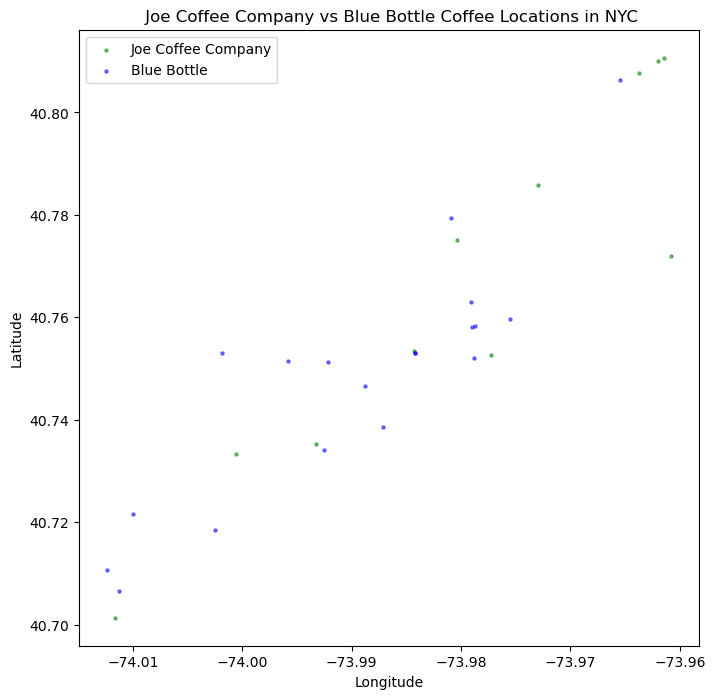

In [16]:
# Plot Starbucks and Blue Bottle stores on the same scatter plot
plt.figure(figsize=(8, 8))

# Scatter plot for Joe locations
plt.scatter(
    df_joe['Longitude'], df_joe['Latitude'],
    s=5, alpha=0.5, color='green', label='Joe Coffee Company'
)

# Scatter plot for Blue Bottle locations
plt.scatter(
    df_blue['Longitude'], df_blue['Latitude'],
    s=5, alpha=0.5, color='blue', label='Blue Bottle'
)


# Add title and labels
plt.title(' Joe Coffee Company vs Blue Bottle Coffee Locations in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Show the plot
plt.show()

## Calculation Analysis 

In [19]:
df_blue.describe()

,Latitude,Longitude,Zip Code,Rating,Review Count
count,19.000000,19.000000,19.000000,19.000000,19.000000
mean,40.748169,-73.989480,10031.000000,3.826316,59.473684
std,0.023615,0.013232,45.802717,0.317704,77.639744
min,40.706510,-74.012330,10001.000000,3.200000,6.000000
25%,40.736311,-73.998829,10006.000000,3.650000,15.500000
50%,40.752060,-73.987138,10018.000000,3.900000,37.000000
75%,40.758152,-73.979041,10022.500000,4.100000,59.000000
max,40.806390,-73.965420,10165.000000,4.300000,331.000000


In [20]:
df_joe.describe()

,Latitude,Longitude,Rating,Review Count
count,11.000000,11.000000,11.000000,11.000000
mean,40.767024,-73.978941,3.963636,165.636364
std,0.035640,0.017210,0.438800,162.700506
min,40.701345,-74.011612,3.300000,6.000000
25%,40.743951,-73.988791,3.850000,13.500000
50%,40.772044,-73.977233,4.000000,143.000000
75%,40.796700,-73.962877,4.100000,310.000000
max,40.810686,-73.960805,5.000000,396.000000


In [25]:
# Extracting the mean rating from the summary statistics
mean_rating_blue = df_blue['Rating'].mean()
mean_rating_joe = df_joe['Rating'].mean()

# Comparison using if-else
if mean_rating_blue > mean_rating_joe:
    print("Blue Bottle Coffee has a higher average rating than Joe Coffee Company.")
elif mean_rating_blue < mean_rating_joe:
    print("Joe Coffee Company has a higher average rating than Blue Bottle Coffee.")
else:
    print("Both Blue Bottle Coffee and Joe Coffee Company have the same average rating.")

# Optional: Print the actual mean ratings for reference
print(f"Blue Bottle Coffee Average Rating: {mean_rating_blue:.2f}")
print(f"Joe Coffee Company Average Rating: {mean_rating_joe:.2f}")

Joe Coffee Company has a higher average rating than Blue Bottle Coffee.
Blue Bottle Coffee Average Rating: 3.83
Joe Coffee Company Average Rating: 3.96


## Clustering Analysis & Comparison with household income

In [26]:
df_blue['Zip Code'].unique()

array([10005, 10013, 10007, 10003, 10001, 10119, 10165, 10018, 10020,
       10022, 10105, 10023, 10025, 10010])

In [27]:
blue_by_zip = df_blue.groupby('Zip Code').size().reset_index(name='Store Count')
blue_by_zip

,Zip Code,Store Count
0,10001,3
1,10003,1
2,10005,1
3,10007,1
4,10010,1
5,10013,2
6,10018,2
7,10020,2
8,10022,1
9,10023,1


In [28]:
df_joe['Zip Code'].unique()

array(['10014', '10003', '10004', '10024', '10023', '10021', '10027',
       '10018', '10017'], dtype=object)

In [29]:
joe_by_zip = df_joe.groupby('Zip Code').size().reset_index(name='Store Count')
joe_by_zip

,Zip Code,Store Count
0,10003,1
1,10004,1
2,10014,1
3,10017,1
4,10018,1
5,10021,1
6,10023,1
7,10024,1
8,10027,3


In [30]:
#import income data to facilitate analysis 

In [31]:
# Load the dataset
df_income = pd.read_excel(r"C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 02\Median household income.xlsx")
df_income.head(2)

,ZipCode,Median_household_income
0,10001,101409
1,10002,37093


In [32]:
# Ensure both 'Zip Code' columns are in the same format (as string)
df_blue['Zip Code'] = df_blue['Zip Code'].astype(str)
df_income['ZipCode'] = df_income['ZipCode'].astype(str)

# Merge the datasets based on 'Zip Code'
df_merged_blue = pd.merge(df_blue, df_income, left_on='Zip Code', right_on='ZipCode', how='inner')

# Drop unnecessary 'ZipCode' column from income data after merging
df_merged_blue.drop(columns=['ZipCode'], inplace=True)

# Save the merged DataFrame to a new CSV
df_merged_blue.to_csv("blue_bottle_with_income.csv", index=False)

df_merged_blue

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price,Median_household_income
0,Blue Bottle Coffee,"22 Broad St, New York, NY 10005",40.706510,-74.011230,10005,4.3,22,N/A,197188
1,Blue Bottle Coffee,"396 Broadway, New York, NY 10013",40.718480,-74.002480,10013,4.1,37,$$,137572
2,Blue Bottle Coffee - New York,"150 Greenwich St, New York, NY 10007",40.710715,-74.012330,10007,4.2,175,$$,250001
3,Blue Bottle Coffee,"408 Greenwich St, New York, NY 10013",40.721594,-74.010010,10013,3.4,8,N/A,137572
4,Blue Bottle Coffee,"101 University Pl, New York, NY 10003",40.734030,-73.992520,10003,4.1,62,$,137533
5,Blue Bottle Coffee,"1227 Broadway, New York, NY 10001",40.746621,-73.988791,10001,3.9,11,N/A,101409
6,Blue Bottle Coffee,"441 8th Ave, Ste 68, New York, NY 10001",40.751537,-73.995835,10001,3.7,20,N/A,101409
7,Blue Bottle Coffee - Hudson Yards,"20 Hudson Yards, Ste 228, New York, NY 10001",40.753119,-74.001823,10001,3.5,97,$$,101409
8,Blue Bottle Coffee - Bryant Park,"54 W 40th St, New York, NY 10018",40.753064,-73.984223,10018,4.0,331,$$,130457
9,Blue Bottle Coffee,"54 W 40th St, New York, NY 10018",40.753080,-73.984160,10018,3.7,9,N/A,130457


In [33]:
df_merged_blue.describe()

,Latitude,Longitude,Rating,Review Count,Median_household_income
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,40.745190,-73.992312,3.814286,70.500000,139460.428571
std,0.026990,0.014102,0.318306,87.566898,40875.414043
min,40.706510,-74.012330,3.200000,8.000000,101409.000000
25%,40.724703,-74.002316,3.625000,20.500000,110194.250000
50%,40.749079,-73.990656,3.850000,40.500000,133872.000000
75%,40.753109,-73.984176,4.075000,80.000000,137572.000000
max,40.806390,-73.965420,4.300000,331.000000,250001.000000


In [34]:
# Ensure both 'Zip Code' columns are in the same format (as string)
df_joe['Zip Code'] = df_joe['Zip Code'].astype(str)
df_income['ZipCode'] = df_income['ZipCode'].astype(str)

# Merge the datasets based on 'Zip Code'
df_merged_joe = pd.merge(df_joe, df_income, left_on='Zip Code', right_on='ZipCode', how='inner')

# Drop unnecessary 'ZipCode' column from income data after merging
df_merged_joe.drop(columns=['ZipCode'], inplace=True)

# Save the merged DataFrame to a new CSV
df_merged_joe.to_csv("joe_coffee_with_income.csv", index=False)

df_merged_joe

,Name,Address,Latitude,Longitude,Zip Code,Rating,Review Count,Price,Median_household_income
0,Joe Coffee Company,"141 Waverly Pl, New York, NY 10014",40.733297,-74.000566,10014,4.1,380,$,136559
1,Joe Coffee Company,"9 E 13th St, New York, NY 10003",40.735171,-73.993262,10003,3.9,359,$$,137533
2,Joe Coffee Company,"7 South St Slip, New York, NY 10004",40.701345,-74.011612,10004,3.4,18,N/A,216017
3,Joe Coffee Company,"514 Columbus Ave, New York, NY 10024",40.785768,-73.972978,10024,4.0,396,$,153177
4,Joe Coffee Company,"187 Columbus Ave, New York, NY 10023",40.775080,-73.980367,10023,4.0,143,$,136109
5,Joe Coffee Company,"1045 Lexington Ave, New York, NY 10021",40.772044,-73.960805,10021,4.1,261,$,136060
6,Joe Coffee Company,"550 W 120th St, New York, NY 10027",40.810050,-73.962020,10027,3.8,216,$$,58435
7,Joe Coffee Company,"55 W 40th St, Ste 9, Bryant Park, New York, NY...",40.753458,-73.984319,10018,3.3,26,$$,130457
8,Joe Coffee Company,"105 E 42nd St Grand Central Dining Concourse, ...",40.752731,-73.977233,10017,4.1,9,N/A,136112
9,Joe Coffee Company,"305 Dodge Hall, 305 Dodge Hall, Upper Campus L...",40.810686,-73.961453,10027,5.0,6,N/A,58435


In [35]:
df_merged_joe.describe()

,Latitude,Longitude,Rating,Review Count,Median_household_income
count,11.000000,11.000000,11.000000,11.000000,11.000000
mean,40.767024,-73.978941,3.963636,165.636364,123393.545455
std,0.035640,0.017210,0.438800,162.700506,47991.689988
min,40.701345,-74.011612,3.300000,6.000000,58435.000000
25%,40.743951,-73.988791,3.850000,13.500000,94446.000000
50%,40.772044,-73.977233,4.000000,143.000000,136109.000000
75%,40.796700,-73.962877,4.100000,310.000000,137046.000000
max,40.810686,-73.960805,5.000000,396.000000,216017.000000


In [36]:
# Extracting the mean rating from the summary statistics
median_income_blue = df_merged_blue['Median_household_income'].mean()
median_income_joe = df_merged_joe['Median_household_income'].mean()

# Comparison using if-else
if median_income_blue > median_income_joe:
    print("Blue Bottle Coffee stores are located in areas with higher average household income.")
elif median_income_blue < median_income_joe:
    print("Joe Coffee Company stores are located in areas with higher average household income.")
else:
    print("Both Blue Bottle Coffee and Joe Coffee Company stores are located in areas with the same average household income.")

# Optional: Print the actual mean incomes for reference
print(f"Blue Bottle Coffee Average Median Household Income: {median_income_blue:.2f}")
print(f"Joe Coffee Company Average Median Household Income: {median_income_joe:.2f}")

Blue Bottle Coffee stores are located in areas with higher average household income.
Blue Bottle Coffee Average Median Household Income: 139460.43
Joe Coffee Company Average Median Household Income: 123393.55


In [39]:
import os

# Set the folder path where your CSV files are located
folder_path = r'C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 02'  

# Create an empty list to store dataframes
dataframes = []

# Loop through all the files in the folder
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Combine all the dataframes into one
combined_df = pd.concat(dataframes, ignore_index=True)

# Save the combined DataFrame to a new CSV
combined_df.to_csv('Coffee_Chain_Manhattan_data.csv', index=False)

print("CSV files combined successfully!")

CSV files combined successfully!
